In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 110

In [2]:
metrics = ['AP', 'AP_Green', 'AP_Red', 'AP50', 'AP75', 'APl', 'APm', 'APs']

default_gw = pd.DataFrame({
    'RGB':         [55.31, 57.23, 53.39,  80.72, 65.55, 84.55, 57.61, 19.15],
    'RGB-D Early': [55.41, 52.17, 58.65,  82.79, 62.42, 78.13, 58.59, 13.81],
    'DCA_0':       [56.51, 53.37, 59.65,  84.60, 63.23, 79.46, 59.56, 17.77],
    'DCA_1':       [56.22, 52.515, 59.931, 84.33, 64.03, 79.43, 59.03, 17.18],
    'DCA_2':       [56.46, 52.72, 60.20,  82.70, 62.57, 86.58, 65.89,  8.61],
}, index=metrics)

gw2 = pd.DataFrame({
    'RGB':         [54.08, 56.89, 51.27, 78.29, 63.41, 85.10, 62.38,  7.33],
    'RGB-D Early': [56.40, 52.30, 60.50, 83.47, 65.53, 83.56, 64.75,  8.80],
    'DCA_0':       [56.17, 52.89, 59.45, 82.82, 63.73, 85.05, 64.31, 11.69],
    'DCA_1':       [55.61, 52.79, 58.44, 82.15, 64.87, 78.56, 64.16, 12.19],
    'DCA_2':       [56.81, 53.79, 59.83, 85.19, 65.36, 83.02, 64.90, 10.64],
    'DCA_3':       [56.17, 53.20, 59.14, 83.80, 64.39, 80.59, 64.55,  9.03],
    'DCA_4':       [55.48, 52.52, 58.45, 82.06, 63.43, 81.53, 64.26, 11.67],
}, index=metrics)

gw2

,RGB,RGB-D Early,DCA_0,DCA_1,DCA_2,DCA_3,DCA_4
AP,54.08,56.40,56.17,55.61,56.81,56.17,55.48
AP_Green,56.89,52.30,52.89,52.79,53.79,53.20,52.52
AP_Red,51.27,60.50,59.45,58.44,59.83,59.14,58.45
AP50,78.29,83.47,82.82,82.15,85.19,83.80,82.06
AP75,63.41,65.53,63.73,64.87,65.36,64.39,63.43
APl,85.10,83.56,85.05,78.56,83.02,80.59,81.53
APm,62.38,64.75,64.31,64.16,64.90,64.55,64.26
APs,7.33,8.80,11.69,12.19,10.64,9.03,11.67


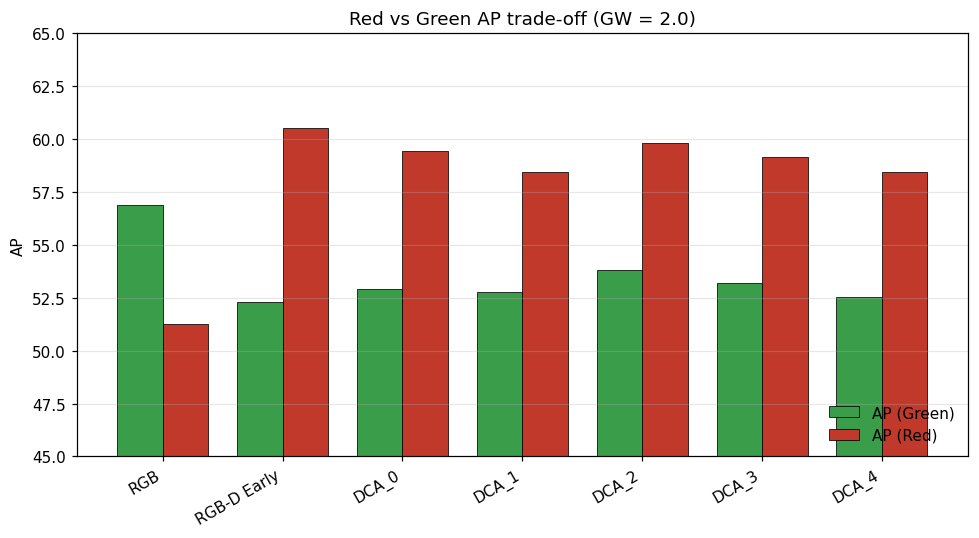

In [3]:
df = gw2  # swap to default_gw to see the other GW setting
variants = df.columns.tolist()
x = np.arange(len(variants))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, df.loc['AP_Green'], w, label='AP (Green)',
       color='#3a9d4a', edgecolor='black', linewidth=0.5)
ax.bar(x + w/2, df.loc['AP_Red'],   w, label='AP (Red)',
       color='#c0392b', edgecolor='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(variants, rotation=30, ha='right')
ax.set_ylabel('AP'); ax.set_title('Red vs Green AP trade-off (GW = 2.0)')
ax.set_ylim(45, 65); ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout(); plt.show()

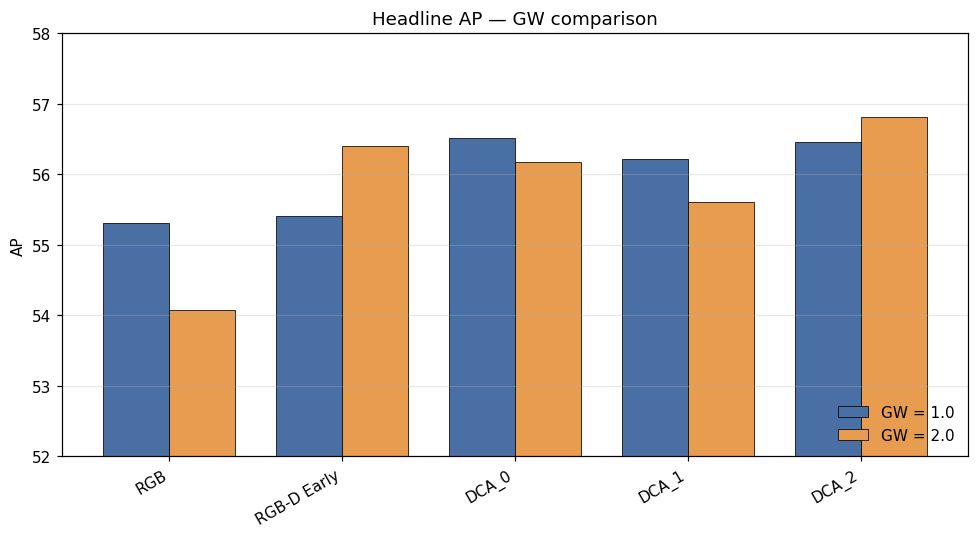

In [4]:
shared = ['RGB', 'RGB-D Early', 'DCA_0', 'DCA_1', 'DCA_2']
x = np.arange(len(shared))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, default_gw.loc['AP', shared], w, label='GW = 1.0',
       color='#4a6fa5', edgecolor='black', linewidth=0.5)
ax.bar(x + w/2, gw2.loc['AP', shared],        w, label='GW = 2.0',
       color='#e89c4f', edgecolor='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(shared, rotation=30, ha='right')
ax.set_ylabel('AP'); ax.set_title('Headline AP — GW comparison')
ax.set_ylim(52, 58); ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout(); plt.show()

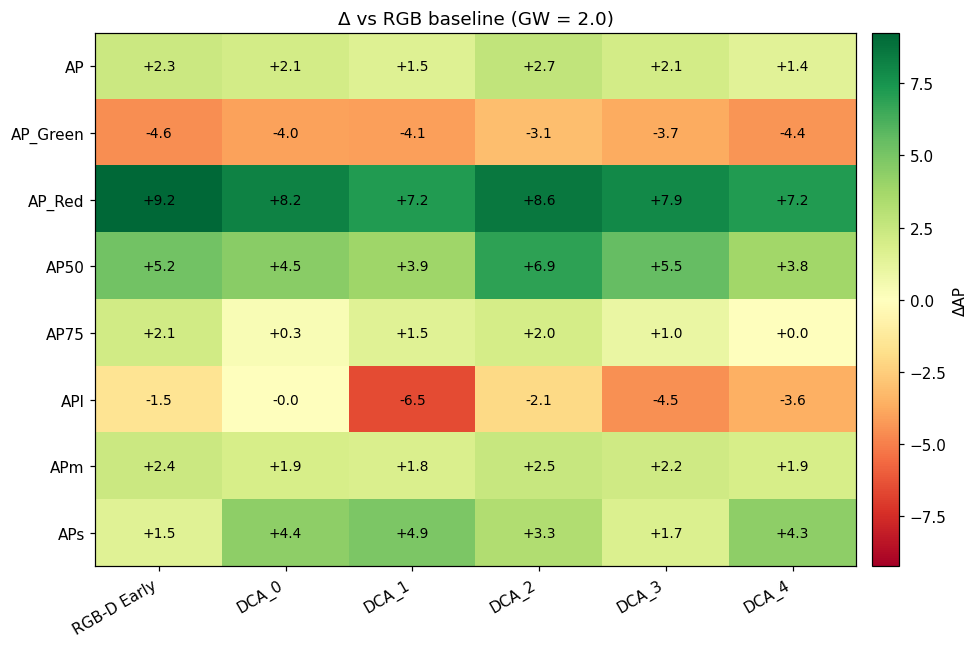

In [5]:
df = gw2
baseline = df['RGB']
delta = df.drop(columns=['RGB']).sub(baseline, axis=0)
vmax = np.abs(delta.values).max()

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(delta.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(delta.columns))); ax.set_xticklabels(delta.columns, rotation=30, ha='right')
ax.set_yticks(range(len(delta.index)));   ax.set_yticklabels(delta.index)
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        ax.text(j, i, f'{delta.values[i, j]:+.1f}', ha='center', va='center',
                fontsize=9, color='black')
ax.set_title('Δ vs RGB baseline (GW = 2.0)')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='ΔAP')
plt.tight_layout(); plt.show()

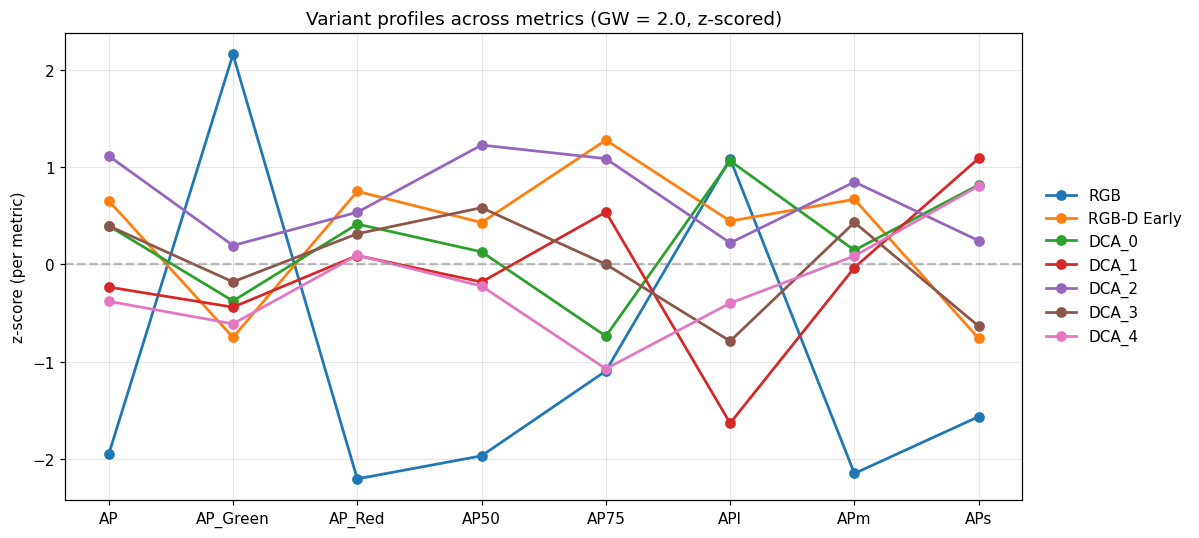

In [6]:
df = gw2
# z-score normalise each metric so they share a y-axis
norm = df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.get_cmap('tab10')
for i, variant in enumerate(norm.columns):
    ax.plot(norm.index, norm[variant], marker='o', label=variant, color=cmap(i), linewidth=1.8)
ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax.set_ylabel('z-score (per metric)')
ax.set_title('Variant profiles across metrics (GW = 2.0, z-scored)')
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout(); plt.show()